**SAC** (Soft Actor Critic), is a an actor-critic method similar to DDPG that includes ideas of Maximum Entropy Reinforcement Learning:
* SAC uses a replay memory and four Q-networks (two Q-networks and their two target Q-networks). The use of two Q-networks is a trick also used in TD3 (DDPG advanced version): to prevent overestimating the Q-value, the minimum value of both estimators is used (thus, it acts like an ensemble).
* SAC uses a policy neural network (actor) to deal with continuous actions, like Policy Gradient methods.
* SAC includes a maximum entropy term $\alpha \log(\pi_{\phi}(s))$ in the optimization that seeks actions that not only provide good value, but also high entropy, thus, enforcing exploration and preventing early convergence to (bad) local minima.

Let us delve into detail on these neural networks:
* The actor takes as input the current state $s_t$, and outputs the parameters of a Gaussian distribution. Thus, contrary to DDPG, each time that the policy is called with the same state, a different action is sampled (although it can be made deterministic by taking as action the mean, which often is done in evaluation).
* The Q-function neural networks take as input both the state $s_t$ *and* the action $a_t$, and the output is a single scalar $q(s_t, a_t)$.

Thus, in SAC, **the state can be continuous and/or discrete, and actions can be continous** (and discrete with some adaptation).

The algorithm works in two main phases:
* First, as in DQN and DDQN, it interacts with the environment and stores experience vectors on the replay memory. Note that the exploration rate is controlled by making use of the entropy parameter $\alpha$, that can be kept constant during training or be scheduled.
* Then, the actor and the Q-function networks are updated. As in DQN/DDQN, we have a target network for each Q-function estimator.
    * To update the Q-functions weights ($\theta_1, \theta_2$), we compute the Bellman term as in DQN/DDQN and update using an MSE criterion. Note that this udpate uses both target networks to build the Bellman term, and the actions for the next states are sampled from the policy:
$$
r_{t}+\gamma \left(\min_{i=\{1,2\}} Q_{\theta_{i, target}}(s_{t+1},\pi_{\phi}(s_{t+1}) - \alpha \log(\pi_{\phi}(s_{t+1}))) \right)
$$
    * To update the actor, we simply maximize the expected Q-value over $\phi$, the parameters of the policy, including the entropy term:
$$
\max_{\phi}\quad\mathbb{E}_{s_{t}} \Big[\min_{i=\{1, 2\}} Q_{\theta_i}(s_{t},\pi_{\phi}(s_{t})) - \alpha \log(\pi_{\phi}(s_{t}))\Big]
$$
    * Finally, both Q-function target networks are updated at a slower rate than the Q-function networks. We could copy weights every once in a while, as we did in the DQN implementation, or use soft replacement as follows (this is the option chosen for this code):
$$
\theta_{i, target}=(1-\tau)\theta_{i,target}+\tau\theta_{i},\quad i=\{1, 2\}
$$

Let's start with the code! First, as usual, we import the main libraries we are going to use for this simple version of SAC, applied to the Cartpole problem. We need to install the Gymnasium library, which implements the Cartpole.

In [19]:
!pip install gymnasium
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions.normal import Normal
import numpy as np
import random
import gymnasium as gym
import matplotlib.pyplot as plt
import math
from collections import deque
import itertools
%matplotlib inline

Next, we are going to create a simple MLP model to create both the actor and the Q-functions. Note that the neural network is quite simple: depending on the problem to be addressed, it may suffice to use simple neural networks in DRL (and hence, it is possible to train using a CPU).

A new parameter appears: final_scale is a scalar used to scale the actions to the right interval. Note that this implementation assumes that action spaces are symmetric, i.e., $a \in [-c, c]$ for some scalar $c$.

In [20]:
class MLP(nn.Module):
    def __init__(self, input_size, output_size, final_activation=None, final_scale=None, hidden_size=128):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size,output_size)
        self.relu = nn.ReLU()
        self.final_activation = final_activation
        self.final_scale = torch.tensor(final_scale, requires_grad=False) if final_scale is not None else None

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        if self.final_activation is not None:
            x = self.final_activation(x)
        if self.final_scale is not None:
            x = x * self.final_scale
        return x

Next, we are going to define the agent. The methods implemented are:
* The **init** method sets up all parameters and initializes the actor and the Q-function. The only new parameter compared to DDPG is the entropy weight $\alpha$, which we consider constant during training.
* The **get_action_and_logprob_from_actor_output** method returns the action limited using a tanh activation and the entropy of the action (corrected to account for the tanh term).
* The **get_action** method returns a sampled action.
* The **append_sample** method adds experience vectors to the memory.
* The **train_step** method is the main update: it collects a batch of samples from the replay memory, and performs the updates on all the neural networks.
* The **train** method is the main method: it takes as input an environment, and proceeds to train the algorithm using the two phases mentioned before: it interacts with the environment in order to add experience vectors to the replay memory, and after each step, performs an update on all the neural networks.

In [27]:
class SACAgent:  # SAC Agent
    def __init__(self, state_size, action_size, action_scale=None, device=None, entropy=1.0):
        # Define state and action space sizes
        self.state_size = state_size
        self.action_size = action_size
        self.action_scale = action_scale  # In this implementation, we assume actions in the range [-action_scale, action_scale]
        self.tau = 0.1  # Parameter for soft update of the target networks
        self.batch_size = 128  # Batch size for replay
        self.train_start = 1000  # Adds a delay, for the memory to have data before starting the training
        self.discount_factor = 0.99  # Discount factor
        self.entropy = entropy # Entropy constant (assumed constant during training)
        # Create a replay memory using deque
        self.memory = deque(maxlen=5000)
        # create the policy model and target model
        if device is None:
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # To use GPU if available
        else:
            self.device = device
        print('SAC is using device: ', self.device)
        # Define all the networks involved
        self.actor = MLP(self.state_size, 2 * self.action_size, final_activation=None, final_scale=None, hidden_size=64).to(self.device) # We output mean and log-std of the policy, see get_action_from_actor_output to the actual action
        self.q1 = MLP(self.state_size + self.action_size, 1, hidden_size=64).to(self.device)
        self.q1_target = MLP(self.state_size + self.action_size, 1, hidden_size=64).to(self.device)
        self.q2 = MLP(self.state_size + self.action_size, 1, hidden_size=64).to(self.device)
        self.q2_target = MLP(self.state_size + self.action_size, 1, hidden_size=64).to(self.device)
        # Initialize target networks
        self.q1_target.load_state_dict(self.q1.state_dict())
        self.q2_target.load_state_dict(self.q2.state_dict())
        # Define the optimizers
        self.learning_rate_actor = 0.001  # Learning rate for ADAM optimizer
        self.learning_rate_q = 0.01  # Learning rate for ADAM optimizer
        self.actor_params = self.actor.parameters()
        self.q_params = itertools.chain(self.q1.parameters(), self.q2.parameters())
        self.actor_optimizer = torch.optim.Adam(self.actor_params, lr=self.learning_rate_actor)
        # Parameters of self.q1 and self.q2
        self.q_optimizer = torch.optim.Adam(self.q_params, lr=self.learning_rate_q)

    # Note that we need to transform the unnormalized actor output to a proper action
    def get_action_and_logprob_from_actor_output(self, states, deterministic=False): # Note that states in this method needs to be a torch vector, states is batch_size x state_size
        actor_output = self.actor(states)
        means, log_stds = actor_output[:, 0: self.action_size], actor_output[:, self.action_size:]
        stds = torch.exp(torch.clamp(log_stds, -20, 2))  # To prevent the std to grow unbounded or go to zero
        policy_distribution = Normal(means, stds)
        if deterministic:
            action = means  # Do not add noise
        else:
            action = policy_distribution.rsample()
        # Compute logprob from Gaussian, and then apply correction for Tanh squashing.
        # Extracted from: https://github.com/openai/spinningup/blob/master/spinup/algos/pytorch/sac/core.py
        # NOTE: The correction formula is a little bit magic. To get an understanding
        # of where it comes from, check out the original SAC paper (arXiv 1801.01290)
        # and look in appendix C. This is a more numerically-stable equivalent to Eq 21.
        # Try deriving it yourself as a (very difficult) exercise. :)
        logp = policy_distribution.log_prob(action).sum(axis=-1)
        logp -= (2*(np.log(2) - action - F.softplus(-2*action))).sum(axis=1)
        return torch.tanh(action) * self.action_scale, logp  # We need to scale the action

    def get_action(self, state, deterministic=False):
        state = np.reshape(state, [1, self.state_size])  # Single state, else, assume that states is batch x state_size
        action = self.get_action_and_logprob_from_actor_output(torch.from_numpy(state).to(self.device), deterministic=deterministic)[0].detach().cpu().numpy()
        return action[0]

    # Save sample <s,a,r,s'> to the replay memory
    def append_sample(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def train_step(self):
        if len(self.memory) < self.train_start:
            return -1, -1  # Start training only when there are some samples in the memory (the -1 value is a flag for the loss)
        # Pick samples randomly from replay memory (with batch_size)
        batch_size = min(self.batch_size, len(self.memory))
        mini_batch = random.sample(self.memory, batch_size)
        # Preprocess the batch by storing the data in different vectors
        states = np.zeros((batch_size, self.state_size))
        next_states = np.zeros((batch_size, self.state_size))
        actions = np.zeros((batch_size, 1))
        rewards = np.zeros((batch_size, 1))
        dones = np.zeros((batch_size, 1))

        for i in range(batch_size):
            states[i] = mini_batch[i][0]
            actions[i] = mini_batch[i][1]
            rewards[i] = mini_batch[i][2]
            next_states[i] = mini_batch[i][3]
            dones[i] = mini_batch[i][4]

        # Convert numpy arrays to torch tensors
        states = torch.Tensor(states).to(self.device)
        next_states = torch.Tensor(next_states).to(self.device)
        actions = torch.Tensor(actions).to(self.device)
        rewards = torch.Tensor(rewards).to(self.device)
        dones = torch.Tensor(dones).type(torch.LongTensor).to(self.device)

        # Train the Q networks
        self.q1.train()
        self.q2.train()
        self.q_optimizer.zero_grad()
        q1_values = self.q1(torch.cat([states, actions], dim=1).to(self.device))
        q2_values = self.q2(torch.cat([states, actions], dim=1).to(self.device))
        with torch.no_grad():  # To prevent gradient computation on the actor, as we do not need it
            next_actions, next_actions_logp = self.get_action_and_logprob_from_actor_output(next_states)
            next_q1_values = self.q1_target(torch.cat([next_states, next_actions], dim=1).to(self.device))
            next_q2_values = self.q2_target(torch.cat([next_states, next_actions], dim=1).to(self.device))
            next_q_values = torch.min(next_q1_values, next_q2_values)  # Element-wise minimum (Q network bias correction)
            # Obtain the Bellman objective
            bellman_term = rewards + self.discount_factor * (1 - dones) * (next_q_values - self.entropy * next_actions_logp)
        # Fit the model!
        q1_loss = torch.mean(torch.square(q1_values - bellman_term))  # MSE loss
        q2_loss = torch.mean(torch.square(q2_values - bellman_term)) # MSE loss
        q_loss = q1_loss + q2_loss
        q_loss.backward()
        self.q_optimizer.step()

        # Now, train the actor network
        self.actor.train()
        self.actor_optimizer.zero_grad()
        # Get the actions predicted by the actor
        actions, actions_logp = self.get_action_and_logprob_from_actor_output(states)
        q1_values = self.q1(torch.cat([states, actions], dim=1).to(self.device))
        q2_values = self.q2(torch.cat([states, actions], dim=1).to(self.device))
        q_values = torch.min(q1_values, q2_values)
        a_loss = -torch.mean(q_values - self.entropy * actions_logp) # Note that the minus sign is because the actor trains using gradient ascent (i.e., maximization)
        a_loss.backward()
        self.actor_optimizer.step()

        # Soft update of the target networks (we could also copy weights once in a while, as in DQN code)
        for target_param, param in zip(self.q1_target.parameters(), self.q1.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)
        for target_param, param in zip(self.q2_target.parameters(), self.q2.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

        self.actor.eval()  # Set the model back to evaluation mode
        self.q1.eval()  # Set the model back to evaluation mode
        self.q2.eval()

        return q_loss.item(), a_loss.item()

    def train(self, env, max_episodes=300, verbose=True, verbose_interval=10):

        scores, episodes, losses = [], [], [] # To store values for plotting
        break_flag = False  # To stop training when the agent has successfully learned

        for e in range(max_episodes):
            if break_flag:
                break
            done = False
            score = 0
            state = env.reset(seed=np.random.randint(1000))  # Set the initial state
            state = np.reshape(state, [1, self.state_size])
            ql = []  # To store the loss values of the episode
            al = []  # To store the loss values of the episode

            while not done:  # Iterate while the game has not finished
                action = self.get_action(state)
                next_state, reward, terminated, truncated, info = env.step(action)
                done = terminated or truncated
                next_state = np.reshape(next_state, [1, self.state_size])

                # Save the sample <s, a, r, s'> to the replay memory
                self.append_sample(state, action, reward, next_state, done)

                # Train
                q_loss, a_loss = self.train_step()

                score += reward
                state = next_state
                ql.append(q_loss)
                al.append(a_loss)

                if done:
                    # Store values for plotting
                    scores.append(score)
                    episodes.append(e)
                    losses.append((np.mean(ql), np.mean(al)))
                    # Output the results of the episode
                    if verbose and e % verbose_interval == 0:
                        print("episode:", e, "  score:", score, "  memory length:", len(agent.memory),
                              "q-loss:", losses[-1][0],  " a-loss:", losses[-1][1])

                    # Stop if mean scores of last 5 episodes is higher than 490
                    if np.mean(scores[-min(5, len(scores)):]) > 490:
                        break_flag = True

        # Output whether the agent learnt or not
        if break_flag:
            print("Training finished successfully")
        else:
            print("Training finished unsuccessfully")

        return episodes, scores, losses

Let us now describe the environment where we are going to train our agent: the Cartpole problem. We have a moving cart with a pole and a mass on top, and want to keep the pole vertical.

* The state set is continuous and has 4 components: pole angle and angular speed, and cart position and velocity.

* The standard Cartpole has a discrete set of actions. In order to prevent that, we prepare a custom version of the Cartpole environment, where the action is continuous and is the force applied to the cart, where $A=[-10, 10]$ is the interval of possible forces.

* The rewards are $+1$ for every time step that the pole has not fallen: if the pole surpasses a certain angle (i.e., it falls), the episode terminates.

In [22]:
class ContinuousCartPoleEnv(object):  # Modified from the original env to have continuous actions

    def __init__(self):
        self.gravity = 9.8
        self.masscart = 1.0
        self.masspole = 0.1
        self.total_mass = self.masspole + self.masscart
        self.length = 0.5  # actually half the pole's length
        self.polemass_length = self.masspole * self.length
        self.force_mag = 10.0
        self.tau = 0.02  # seconds between state updates
        self.kinematics_integrator = "euler"

        # Angle at which to fail the episode
        self.theta_threshold_radians = 12 * 2 * math.pi / 360
        self.x_threshold = 2.4

        # Angle limit set to 2 * theta_threshold_radians so failing observation
        # is still within bounds.
        high = np.array([self.x_threshold * 2, np.finfo(np.float32).max,
                         self.theta_threshold_radians * 2,
                         np.finfo(np.float32).max,], dtype=np.float32,)

        self.observation_space = gym.spaces.Box(-high, high, dtype=np.float32)

        high = np.array([self.force_mag], dtype=np.float32,)

        self.action_space = gym.spaces.Box(-high, high, dtype=np.float32, )

        self.screen = None
        self.clock = None
        self.isopen = True
        self.state = None
        self.t = 0
        self.max_t = 500

        self.steps_beyond_done = None

    def step(self, action):
        #err_msg = f"{action!r} ({type(action)}) invalid"
        #assert self.action_space.contains(action), err_msg
        #assert self.state is not None, "Call reset before using step method."
        x, x_dot, theta, theta_dot = self.state
        force = action.item()
        costheta = math.cos(theta)
        sintheta = math.sin(theta)

        # For the interested reader:
        # https://coneural.org/florian/papers/05_cart_pole.pdf
        temp = (
            force + self.polemass_length * theta_dot**2 * sintheta
        ) / self.total_mass
        thetaacc = (self.gravity * sintheta - costheta * temp) / (
            self.length * (4.0 / 3.0 - self.masspole * costheta**2 / self.total_mass)
        )
        xacc = temp - self.polemass_length * thetaacc * costheta / self.total_mass

        if self.kinematics_integrator == "euler":
            x = x + self.tau * x_dot
            x_dot = x_dot + self.tau * xacc
            theta = theta + self.tau * theta_dot
            theta_dot = theta_dot + self.tau * thetaacc
        else:  # semi-implicit euler
            x_dot = x_dot + self.tau * xacc
            x = x + self.tau * x_dot
            theta_dot = theta_dot + self.tau * thetaacc
            theta = theta + self.tau * theta_dot

        self.state = (x, x_dot, theta, theta_dot)

        self.t += 1

        done = bool(
            x < -self.x_threshold
            or x > self.x_threshold
            or theta < -self.theta_threshold_radians
            or theta > self.theta_threshold_radians
            or self.t >= self.max_t
        )

        if not done:
            reward = 1.0
        elif self.steps_beyond_done is None:
            # Pole just fell!
            self.steps_beyond_done = 0
            reward = 1.0
        else:
            if self.steps_beyond_done == 0:
                gym.logger.warn(
                    "You are calling 'step()' even though this "
                    "environment has already returned done = True. You "
                    "should always call 'reset()' once you receive 'done = "
                    "True' -- any further steps are undefined behavior."
                )
            self.steps_beyond_done += 1
            reward = 0.0

        return np.squeeze(np.array(self.state, dtype=np.float32)), reward, done, done, {}  # Artificial here: return done twice, for new gymnasium interface

    def reset(self, seed=None):
        if seed is not None:
            rng = np.random.default_rng(seed)
        else:
            rng = np.random.default_rng()
        self.state = rng.uniform(low=-0.05, high=0.05, size=(4,))
        self.steps_beyond_done = None
        self.t = 0
        return np.squeeze(np.array(self.state, dtype=np.float32))

# Load the environment that has been defined
env = ContinuousCartPoleEnv()

A known problem of DRL are the reproducibility issues (see Henderson, P., Islam, R., Bachman, P., Pineau, J., Precup, D., & Meger, D. (2018, April). Deep reinforcement learning that matters. In Proceedings of the AAAI conference on artificial intelligence (Vol. 32, No. 1), https://doi.org/10.48550/arXiv.1709.06560).

To prevent that, the code is seeded: note that changing the seed will change the results, as DRL is known to be extremely sensitive to the initial conditions.

In [23]:
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

We are finally ready! Now, we can train our agent and see what they learn. In order to show the differences between seeds, we are going to run $3$ different initial seeds: note how they have very different convergence properties, in spite of the fact that all hyperparameters are the same, except for the seed!

In [28]:
trials = 3
episodes, scores, losses = [], [], []

for i in range(trials):
    print("Trial {}/{}".format(i + 1, trials))
    # Create the agent
    agent = SACAgent(env.observation_space.shape[0], env.action_space.shape[0],
                      action_scale=env.action_space.high.item(), device='cpu', entropy=0.1)
    # Train the agent
    e, s, l = agent.train(env, max_episodes=300, verbose=True, verbose_interval=10)
    episodes.append(e)
    scores.append(s)
    losses.append(l)

Trial 1/3
SAC is using device:  cpu
episode: 0   score: 26.0   memory length: 26 q-loss: -1.0  a-loss: -1.0
episode: 10   score: 29.0   memory length: 316 q-loss: -1.0  a-loss: -1.0
episode: 20   score: 32.0   memory length: 631 q-loss: -1.0  a-loss: -1.0
episode: 30   score: 23.0   memory length: 940 q-loss: -1.0  a-loss: -1.0
episode: 40   score: 32.0   memory length: 1181 q-loss: 3.002014271914959  a-loss: -13.877015680074692
episode: 50   score: 459.0   memory length: 3277 q-loss: 10.151592085044628  a-loss: -62.98005976292563
Training finished successfully
Trial 2/3
SAC is using device:  cpu
episode: 0   score: 24.0   memory length: 24 q-loss: -1.0  a-loss: -1.0
episode: 10   score: 27.0   memory length: 285 q-loss: -1.0  a-loss: -1.0
episode: 20   score: 28.0   memory length: 520 q-loss: -1.0  a-loss: -1.0
episode: 30   score: 16.0   memory length: 705 q-loss: -1.0  a-loss: -1.0
episode: 40   score: 18.0   memory length: 960 q-loss: -1.0  a-loss: -1.0
episode: 50   score: 201.0  

Now, we plot the results: note that some seeds learn, and others do not, just because of the seed. Thus, it is good practice in DRL to run an algorithm several times, over 8-10 seeds, and then average the results of the best 3-5 seeds.

Note that since actor losses will always be negative, we plot its negative value (thus, higher is better).

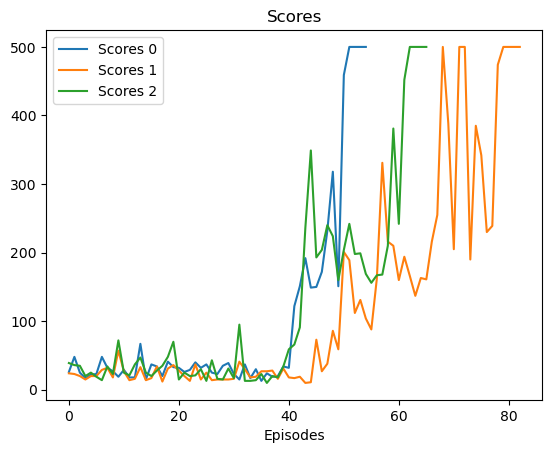

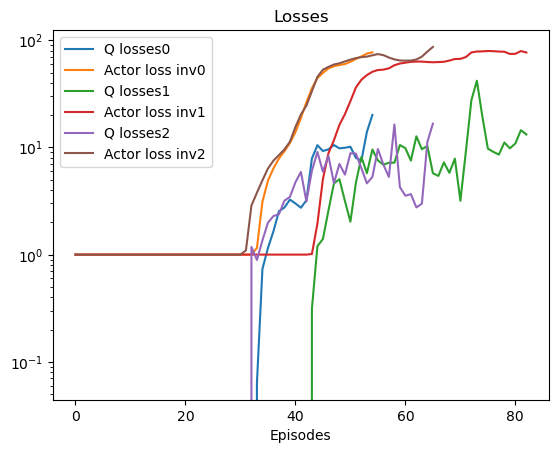

In [29]:
# Plot the scores and losses vs the episodes
fig, ax1 = plt.subplots()

for i in range(trials):
    ax1.plot(episodes[i], scores[i], label='Scores ' + str(i))

ax1.set_xlabel('Episodes')
plt.legend(loc='best')
plt.title('Scores')
plt.show()

# Plot the losses
fig, ax1 = plt.subplots()

for i in range(trials):
    ax1.semilogy(episodes[i], [l[0] for l in losses[i]], label='Q losses' + str(i))
    ax1.plot(episodes[i], [-l[1] for l in losses[i]], label='Actor loss inv' + str(i))

ax1.set_xlabel('Episodes')
plt.legend(loc='best')
plt.title('Losses')
plt.show()

Finally, we will visualize the learned policy. We use deterministic actions to exploit.

Obtaining data from trained network
Data obtained
Creating animation


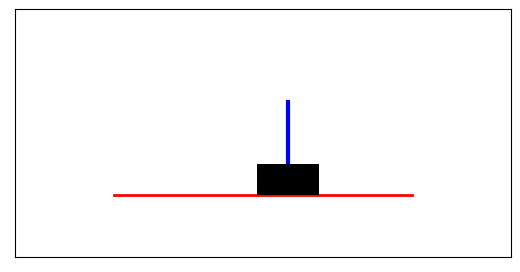

In [31]:
# Run the game once with the trained network and store the values of the position and angle of the cartpole
print("Obtaining data from trained network")
pos_vector=[]
angle_vector=[]
state = env.reset()
state = np.reshape(state, [1, agent.state_size])
done=False
while not done:
    pos_vector.append(state[0,0])
    angle_vector.append(state[0,2])
    action = agent.get_action(state, deterministic=True)
    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    next_state = np.reshape(next_state, [1, agent.state_size])
    state = next_state
    if done:
        break
T=len(pos_vector)
print("Data obtained")

# Animate the data: to observe what our network has learned
from matplotlib import animation, patches
from IPython.display import HTML
print("Creating animation")
fig = plt.figure()
ax = plt.axes(xlim=(-4, 4), ylim=(-1, 3), aspect=1)
ax.set_xticks([])
ax.set_yticks([])

mag1 = plt.Rectangle((0,0), width= 1, height= 0.5, angle=0, fc='black', alpha=0)
line1, = ax.plot([], [], 'b', zorder=1,linewidth=3.0)
line2, = ax.plot([], [], 'r', zorder=1,linewidth=2.0)

def init():
    line1.set_data([], [])
    line2.set_data([], [])
    ax.add_patch(mag1)
    return mag1, line1, line2,

def animate(i):
    mag1.set_alpha(1)
    mag1.xy = (pos_vector[i],0)
    x0=pos_vector[i]+0.5
    y0=0.5
    x1=x0+np.cos(np.pi/2-angle_vector[i])
    y1=y0+np.sin(np.pi/2-angle_vector[i])
    line1.set_data([x0, x1], [y0, y1])
    line2.set_data([-2.4, 2.4], [0,0])
    return mag1, line1, line2,

anim = animation.FuncAnimation(fig, animate, init_func=init, frames=T,
                               interval=25, blit=True)

HTML(anim.to_jshtml())